# 了解Python性能

本节结束后您将能够回答的问题
- 计算机体系结构的要素是什么？
- 有哪些常见的替代计算机体系结构？
- Python如何抽象底层的计算机体系结构？
- 制作高性能的Python代码有哪些障碍？
- 什么策略可以帮助你成为一个高性能的程序员？

计算机编程可以被认为是移动数据位，并以特殊的方式对其进行转换，以获得特定的结果。然而，这些行动有时间成本。因此，高性能编程可以被认为是通过减少开销（即编写更有效的代码）或通过改变执行这些操作的方式使每个操作更有意义（即找到更合适的算法）来最小化这些操作的行为。

让我们集中精力减少代码中的开销，以便更深入地了解移动这些位的实际硬件。这似乎是徒劳的练习，因为Python很难抽象出与硬件的直接交互。但是，通过了解在实际硬件中移动位的最佳方式以及Python的抽象迫使位移动的方式，可以在用Python编写高性能程序方面取得进展。

## 计算机基础系统

构成计算机的底层组件可以简化为三个基本部分：计算单元、内存单元和它们之间的连接。此外，这些单元中的每一个都有不同的性质，我们可以用来理解它们。计算单元的特性是每秒可以进行多少次计算，存储单元的特性是可以保存多少数据，我们可以读写它的速度有多快，最后，连接的特性是可以将数据从一个地方移动到另一个地方的速度有多快。

使用这些构建块，我们可以讨论多层次复杂度的标准工作站。例如，标准工作站可以被认为具有作为计算单元的中央处理单元（CPU），作为两个独立的存储器单元（每个单元具有不同的容量和读/写速度）连接到随机存取存储器（RAM）和硬盘驱动器，最后是提供所有这些部件之间连接的总线。但是，我们也可以更详细地了解CPU本身有几个内存单元：L1、L2，有时甚至L3和L4缓存，它们的容量很小，但速度非常快（从几千字节到十几兆字节）。此外，新的计算机体系结构通常伴随着新的配置（例如，Intel的SkyLake CPU用Intel Ultra Path互连取代了前端总线，并重组了许多连接）。最后，在工作站的这两个近似值中，我们忽略了网络连接，这实际上是一个非常缓慢的连接，可能会连接到许多其他计算和内存单元！

为了帮助解开这些错综复杂的问题，让我们简单描述一下这些基本块。

### 计算单元

计算机的计算单元是它有用性的核心，它提供了将接收到的任何位转换为其他位或改变当前进程状态的能力。CPU是最常用的计算单元；然而，图形处理单元（GPU）作为辅助计算单元越来越受欢迎。它们最初被用来加速计算机图形，但越来越适用于数值应用，并且由于它们的本质并行性而变得有用，这使得许多计算同时发生。无论其类型如何，计算单元都会接收一系列位（例如，表示数字的位），并输出另一组数字的位（例如，表示这些数字的和的位）。除了对整数和实数的基本算术运算和二进制数的位运算外，一些计算单元还提供了非常专门的操作，例如“混合乘法加法”运算，它包含三个数字，A、B和C，并返回值 `A*B+C`。

计算单元感兴趣的主要特性是它可以在一个周期内执行的操作数和它在一秒钟内可以执行的循环数。第一个值是通过其每循环指令（IPC）测量的，而后一个值则是通过其时钟速度测量的。这两种措施在新的计算单元正在制造时总是相互竞争。例如，英特尔核心系列的IPC非常高，但时钟速度较低，而奔腾4芯片则相反。另一方面，GPU具有很高的IPC和时钟速度，但它们还面临着其他问题，比如我们在“通信层”中讨论的通信速度慢。

此外，虽然增加时钟速度几乎立即加快了运行在该计算单元上的所有程序（因为它们能够每秒进行更多的计算），但是拥有更高的IPC也会通过改变可能的矢量化水平来极大地影响计算。当CPU一次提供多个数据块，并且能够同时对所有数据进行操作时，就会发生矢量化。这种CPU指令称为单指令、多数据（SIMD）。

一般来说，过去十年中，计算单元的发展速度相当缓慢（见下图）。由于晶体管越来越小，物理上的限制，时钟速度和IPC都停滞不前。因此，芯片制造商一直依赖其他方法来提高速度，包括同时多线程（多线程可以同时运行）、更聪明的无序执行和多核架构。

超线程（Hyperthreading）向主机操作系统（OS）提供了一个虚拟的第二个CPU，而聪明的硬件逻辑试图在单个CPU上将两个指令线程交织到执行单元中。成功后，可以实现单个线程的30%的收益。通常，当两个线程的工作单元使用不同类型的执行单元时，这一点很好，例如，一个执行浮点操作，另一个执行整数操作。

无序执行（Out-of-order）使编译器能够发现线性程序序列的某些部分不依赖于前一个工作的结果，因此这两个工作都可能以任何顺序或同时发生。只要在适当的时间给出顺序结果，程序仍然能正确执行，即使计算出的工作部分超出了编程顺序。这使得某些指令能够在其他指令被阻止时执行（例如，等待内存访问），从而允许更大的总体利用可用资源。

最后，对于高级程序员来说，最重要的是，多核体系结构的流行。这些架构包括同一单元中的多个CPU，这可以增加总的能力，而不会遇到阻碍，使每个单元更快。这就是为什么目前很难找到任何一台核少于两个的机器，在这种情况下，计算机有两个物理计算单元，彼此连接。虽然这增加了每秒可以执行的操作总数，但这会使编写代码更加困难！

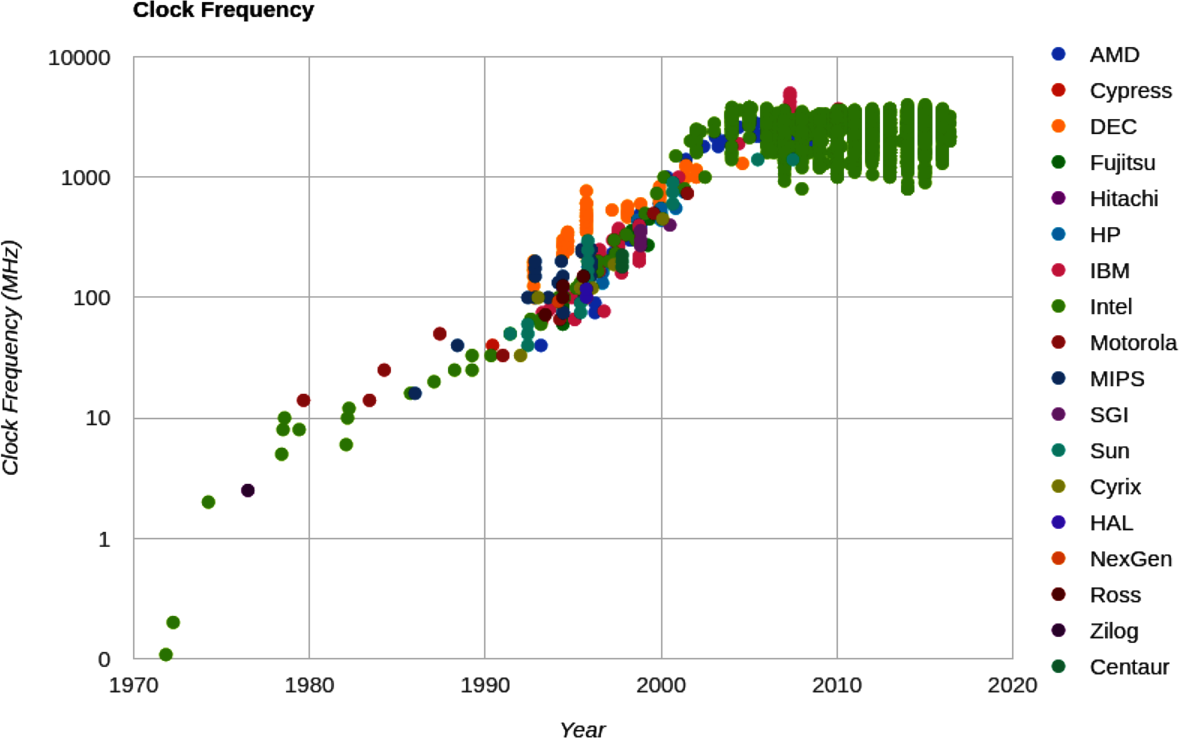

图 CPU随时间变化的时钟速度（来自CPU DB）

简单地向CPU添加更多的内核并不总是能加快程序的执行时间。这是因为阿姆达定律。简单地说，阿姆达尔定律是这样的：如果一个程序设计为在多个核上运行，有一些子程序必须在一个核上运行，这将是通过分配更多核来实现最大加速的限制。

例如，如果我们有一个调查需要100人填写，而这个调查需要1分钟才能完成，那么如果我们有一个人提问，我们可以在100分钟内完成这个任务（即，这个人去参与者1，提问，等待回答，然后移到参与者2）。这种让一个人提问并等待回答的方法类似于一个串行过程。在串行过程中，我们一次只满足一个操作，每个操作都等待前一个操作完成。

然而，如果我们有两个人问问题，我们可以同时进行调查，这样我们只需50分钟就可以完成整个过程。这是因为每个提问的人都不需要知道其他人的任何情况。因此，任务可以很容易地分解，而不需要提问者之间有任何依赖关系。

增加更多的人提问将给我们更多的加速，直到我们有100人提问。在这一点上，这一过程将需要1分钟，并将受到参与者回答问题所需时间的限制。增加更多的人提问不会导致任何进一步的加速，因为这些额外的人将没有任务来执行所有参与者已经被问到的问题！在这一点上，减少运行调查的总时间的唯一方法是减少完成单个调查（问题的序列部分）所需的时间。类似地，使用CPU，我们可以添加更多的内核，这些内核可以根据需要执行各种计算块，直到达到瓶颈点，即特定内核完成其任务所需的时间。换句话说，任何并行计算中的瓶颈总是分散的较小的串行任务。

此外，在Python中使用多核的一个主要障碍是Python使用全局解释器锁（GIL）。GIL确保Python进程一次只能运行一条指令，而不管它当前使用的核数是多少。这意味着，即使某些Python代码一次可以访问多个内核，但在任何给定时间只有一个内核在运行Python指令。以前面的调查为例，这意味着即使我们有100个提问者，一次也只能有一个人提出一个问题并听取回答。这有效地消除了多个提问者的任何好处！虽然这似乎是一个相当大的障碍，特别是如果当前的计算趋势是拥有多个计算单元而不是拥有更快的计算单元，这个问题可以通过使用其他标准库工具来避免，比如 多进程，numpy,numexpr,Cython或分布式计算模型。

### 存储单元

计算机中的存储单元用来存储位。它们可以是表示程序中变量的位，也可以是表示图像像素的位。因此，存储单元的抽象应用于主板以及RAM和硬盘驱动器中的寄存器。所有这些类型的存储单元之间的一个主要区别是它们读取/写入数据的速度。更复杂的是，读/写速度在很大程度上取决于读取数据的方式。

例如，大多数存储单元在读取一大块数据时的性能要比读取许多小块数据时好得多（这称为顺序读取与随机数据）。如果这些内存单元中的数据被认为是一本大书中的页面，这意味着大多数内存单元在逐页浏览书籍时具有更好的读/写速度，而不是不断地从一个随机页面翻到另一个随机页面。虽然这一事实通常适用于所有内存单元，但它对每种类型的影响量却大不相同。

除了读/写速度之外，存储单元还有延迟，其特征是设备查找正在使用的数据所花费的时间。对于正在旋转的硬盘驱动器，这种延迟可能会很高，因为磁盘需要物理上旋转到最高速度，并且读取头必须移动到正确的位置。另一方面，对于RAM，这个延迟可能非常小，因为所有的东西都是固态的。以下是标准工作站中常见的各种内存单元的简短描述，按读/写速度顺序排列：:
1. 旋转硬盘

长期存储，即使计算机关闭也能保持。通常读/写速度较慢，因为磁盘必须进行物理旋转和移动。随机存取模式性能下降，但容量非常大（10TB范围）。
2. 固态硬盘

类似于旋转硬盘，读/写速度更快，但容量更小（1 TB范围）。

3. RAM

用于存储应用程序代码和数据（例如正在使用的任何变量）。具有快速读/写特性，在随机存取模式下表现良好，但通常容量有限（64GB范围）。

4. 一级/二级缓存（L1/L2 cache）

读写速度极快。进入CPU的数据必须经过这里。非常小的容量（兆字节范围）。

下图通过查看当前可用消费类硬件的特性，给出了这些类型存储单元之间差异的图形表示。

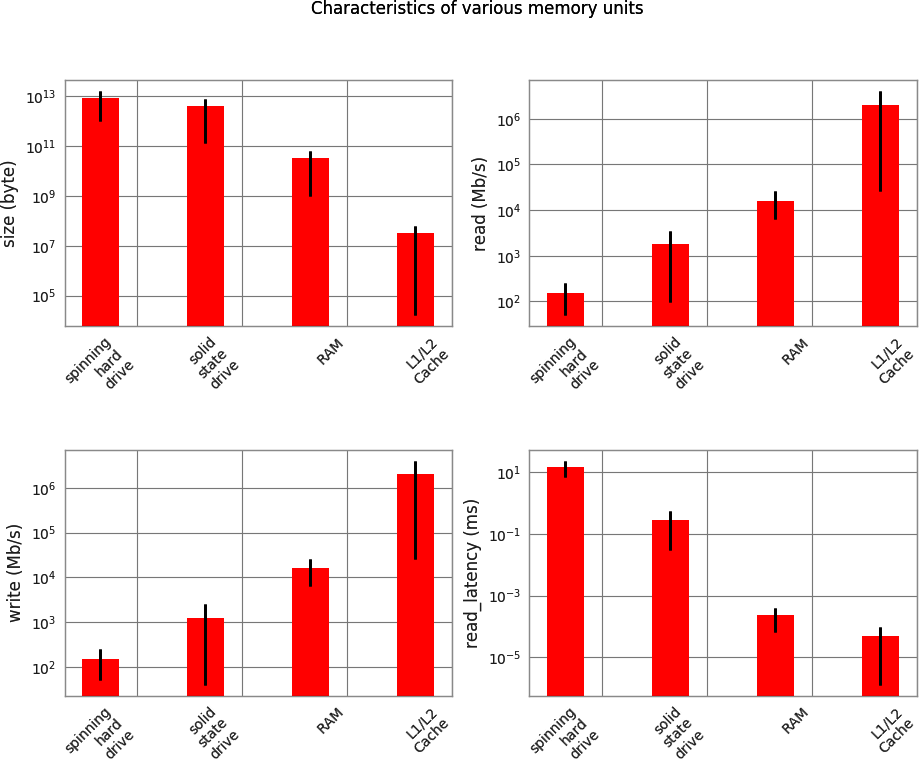

一个显而易见的趋势是读写速度和容量成反比，当我们试图提高速度时，容量就会减少。因此，许多系统对内存采用分层方法：数据在硬盘驱动器中以其完整状态开始，部分数据移动到RAM，然后更小的子集移动到一级/二级缓存。这种分层方法使程序能够根据访问速度要求将内存保留在不同的位置。当试图优化程序的内存模式时，我们只是简单地优化哪些数据被放置在何处、如何布局（以增加顺序读取的次数）以及它在不同位置之间移动的次数。此外，异步I/O和抢占式缓存等方法提供了一些方法，可以确保数据始终位于需要的位置，而不必浪费计算时间这些过程中的大多数都可以独立进行，同时执行其他计算！

### 通信层

最后，让我们看看所有这些基本块是如何相互通信的。存在许多通信方式，但都是总线上的变体。

例如，前端总线是RAM和一级/二级缓存之间的连接。它将准备好由处理器转换的数据移动到暂存场以准备计算，并将完成的计算移出。还有其他总线，例如外部总线，它充当从硬件设备（如硬盘驱动器和网卡）到CPU和系统内存的主要路由。这种外部总线通常比前端总线慢。

事实上，一级/二级缓存的许多好处都归功于更快的总线。能够在慢速总线（从RAM到Cache）上将计算所需的大量数据排队，然后在高速缓存线（从Cache到CPU）中以非常快的速度提供这些数据，这使得CPU能够在不等待这么长时间的情况下进行更多的计算。

类似地，使用GPU的许多缺点来自于它所连接的总线：由于GPU通常是一个外围设备，它通过PCI总线进行通信，这比前端总线慢得多。因此，进出GPU的数据可能是一个相当繁重的操作。异构计算的出现，或者在前端总线上同时有一个CPU和一个GPU的计算块的出现，旨在降低数据传输成本，使GPU计算成为一种可用的选择，即使在必须传输大量数据的情况下也是如此。

除了计算机内的通信层之外，网络可以被认为是另一个通信层。不过，这个层比前面讨论的要柔韧得多；网络设备可以连接到存储器设备，例如网络连接存储（NAS）设备或另一计算层，如在集群中的计算节点。然而，网络通信通常比前面提到的其他类型的通信慢得多。虽然前端总线每秒可以传输几十千兆比特的数据，但网络的传输速率却被限制在几十兆比特左右。

很明显，总线的主要特性是它的速度：在给定的时间内它可以移动多少数据。这个属性由两个量组成：一次传输可以移动多少数据（总线宽度）和总线每秒可以进行多少传输（总线频率）。需要注意的是，在一次传输中移动的数据总是连续的：从内存中读取一块数据并将其移动到不同的位置。因此，总线的速度被分为这两个数量，因为它们可以单独影响计算的不同方面：一个大的总线宽度可以帮助矢量化代码（或任何顺序读取内存的代码），通过使其能够在一次传输中移动所有相关数据，而另一方面，有一个小的总线宽度，但非常高的传输频率可以帮助代码必须做许多读取随机部分的内存。有趣的是，计算机设计者改变这些特性的方式之一是通过主板的物理布局：当芯片彼此靠近放置时，连接它们的物理导线的长度更小，这可以允许更快的传输速度。此外，电线的数量本身决定了总线的宽度（赋予这个术语真正的物理意义！）。

由于可以对接口进行调优，以便为特定应用程序提供正确的性能，因此有数百种类型也就不足为奇了。下图显示公共接口采样的比特率。请注意，这根本不涉及连接的延迟，它决定了响应数据请求所需的时间（虽然延迟与计算机非常相关，但所使用的接口固有的一些基本限制）。

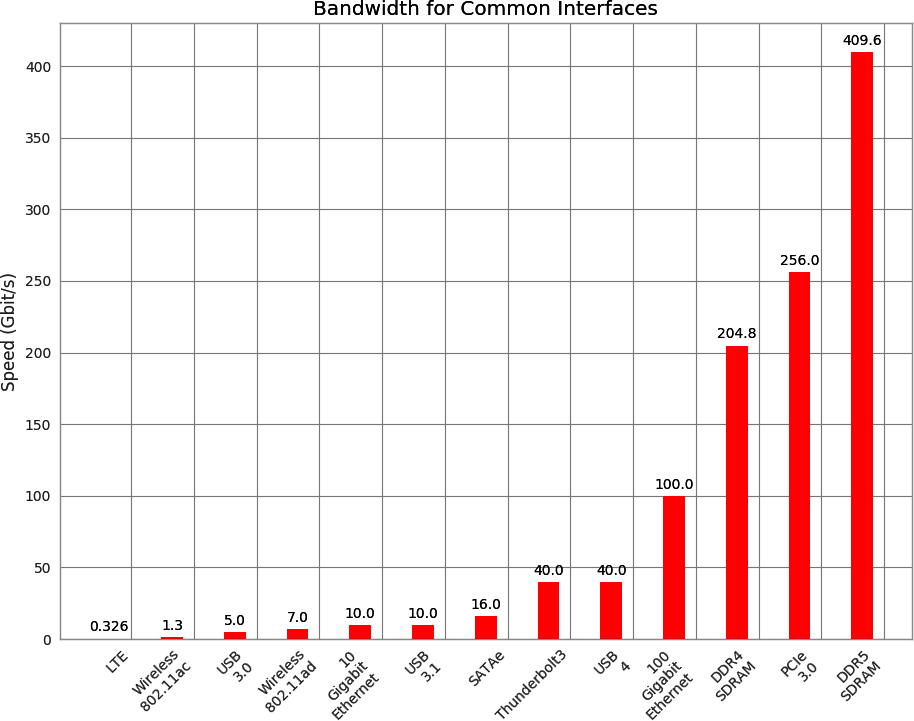

图 各种通用接口的连接速度

## 把基本要素放在一起

理解计算机的基本组成部分不足以完全理解高性能编程的问题。所有这些组件的相互作用以及它们如何协同工作来解决问题会带来额外的复杂性。在本节中，我们将探讨一些有趣的问题，说明理想的解决方案是如何工作的，以及Python是如何处理这些问题的。

备注：大多数人认为Python天生就不能处理性能问题。这是不真实的，有两个原因。首先，在所有“性能计算组件”中，我们忽略了一个非常重要的组件：开发人员。Python在性能上可能缺乏什么，但它会以更快的开发速度迅速恢复。此外，我们将介绍一些模块和原理，这些模块和原理有助于相对轻松地缓解这里描述的许多问题。结合这两个方面，我们将保持Python的快速开发思维，同时消除许多性能限制。

### 理想化计算与Python虚拟机

为了更好地理解高性能编程的组件，让我们看一个简单的代码示例，该示例检查数字是否为素数：

In [1]:
import math

def check_prime(number):
    sqrt_number = math.sqrt(number)
    for i in range(2, int(sqrt_number) + 1):
        if (number / i).is_integer():
            return False
    return True

print(f"check_prime(10,000,000) = {check_prime(10_000_000)}")
# check_prime(10,000,000) = False
print(f"check_prime(10,000,019) = {check_prime(10_000_019)}")
# check_prime(10,000,019) = True

check_prime(10,000,000) = False
check_prime(10,000,019) = True


让我们使用我们的抽象计算模型分析这段代码，然后与Python运行这段代码时发生的情况进行比较。与任何抽象一样，我们将忽略理想化的计算机和Python运行代码的方式中的许多微妙之处。然而，在解决问题之前，这通常是一个很好的练习：考虑算法的一般组件，以及计算组件结合在一起找到解决方案的最佳方式是什么。通过理解这种理想情况并了解Python中实际发生的事情，我们可以迭代地使Python代码更接近最佳代码。

### 理想化计算

当代码开始时，我们将存储在RAM中的数字值。要计算 `sqrt_number`，我们需要将数字的值发送给CPU。理想情况下，我们可以发送一次值；它将被存储在CPU的L1/L2缓存中，CPU将执行计算，然后将值发送回RAM以获得存储。这种情况非常理想，因为我们已经将RAM中的数字值的读取次数减到最小，而选择从L1/L2缓存读取，这要快得多。此外，我们还通过使用直接连接到CPU的L1/L2缓存，将通过前端总线的数据传输数量减到最低。

对于代码中的循环，不是一次向CPU发送一个i值，而是同时向CPU发送数个i值和几个i值以进行检查。这是可能的，因为CPU矢量化操作而没有额外的时间开销，这意味着它可以同时进行多个独立的计算。因此，我们希望向CPU缓存发送数字，以及缓存所能容纳的尽可能多的i值。对于每个number/i对，我们将它们分开，并检查结果是否为整数；然后，我们将发送一个信号，指示是否有任何值确实是整数。如果是，函数结束。如果没有，我们重复。这样，对于i的许多值，我们只需要传回一个结果，而不是依赖于每个值的慢总线。这充分利用了CPU的能力，使计算矢量化，或在一个时钟周期内对多个数据运行一条指令。

以下代码说明了矢量化的概念：

In [2]:
import math

def check_prime(number):
    sqrt_number = math.sqrt(number)
    numbers = range(2, int(sqrt_number)+1)
    for i in range(0, len(numbers), 5):
      # the following line is not valid Python code
        result = (number / numbers[i:(i + 5)]).is_integer()
        if any(result):
            return False
    return True

在这里，我们设置了这样的处理：每次对一组i的五个值进行除法和整数检查。如果正确的矢量化，CPU可以一步完成这一行，而不是对每个i进行单独的计算。理想情况下，任何（结果）操作也会在CPU中发生，而不必将结果传输回RAM。

### PYTHON的虚拟机

Python解释器做了大量工作，试图抽象出正在使用的底层计算元素。程序员根本不需要担心为数组分配内存，如何安排内存，或者以什么顺序将内存发送到CPU。这是Python的一个优点，因为它可以让您专注于正在实现的算法。然而，它要付出巨大的性能代价。

重要的是要认识到，在其核心，Python确实在运行一组非常优化的指令。然而，诀窍是让Python以正确的顺序执行它们以获得更好的性能。例如，很容易看出，在下面的示例中，`search_fast`会比 `search_slow` 运行得更快，这仅仅是因为它跳过了由于没有提前终止循环而导致的不必要的计算，即使两个解决方案都有运行时 `O（n）`。但是，在处理派生类型、特殊Python方法或第三方模块时，事情可能会变得复杂。例如，能否立即判断哪个函数更快：`search_unknown1` 还是 `search_unknown2` ？

In [4]:
import timeit


def search_fast(haystack, needle):
    for item in haystack:
        if item == needle:
            return True
    return False


def search_slow(haystack, needle):
    return_value = False
    for item in haystack:
        if item == needle:
            return_value = True
    return return_value


def search_unknown1(haystack, needle):
    return any((item == needle for item in haystack))


def search_unknown2(haystack, needle):
    return any([item == needle for item in haystack])


if __name__ == "__main__":
    iterations = 10000
    haystack = list(range(1000))
    setup = "from __main__ import (haystack, needle, search_fast, search_slow)"

    needle = 5
    print(
        f"Testing search speed with {len(haystack)} items and needle close to the head of the list"
    )

    t = timeit.timeit(
        stmt="search_fast(haystack, needle)", setup=setup, number=iterations
    )
    print(f"search_fast time: {t/iterations:.5e}")

    t = timeit.timeit(
        stmt="search_slow(haystack, needle)", setup=setup, number=iterations
    )
    print(f"search_slow time: {t/iterations:.5e}")

    needle = len(haystack) - 10
    print(
        f"Testing search speed with {len(haystack)} items and needle close to the tail of the list"
    )

    t = timeit.timeit(
        stmt="search_fast(haystack, needle)", setup=setup, number=iterations
    )
    print(f"search_fast time: {t/iterations:.5e}")

    t = timeit.timeit(
        stmt="search_slow(haystack, needle)", setup=setup, number=iterations
    )
    print(f"search_slow time: {t/iterations:.5e}")

Testing search speed with 1000 items and needle close to the head of the list
search_fast time: 3.69092e-07
search_slow time: 3.54143e-05
Testing search speed with 1000 items and needle close to the tail of the list
search_fast time: 3.45972e-05
search_slow time: 3.51139e-05


通过分析和找到更有效的方法来识别代码的慢区域，类似于找到这些无用的操作并删除它们；最终结果相同，但计算和数据传输的数量却大大减少。

这个抽象层的一个影响是矢量化不能立即实现。我们的初始素数例程将运行一次循环的每一个值i，而不是合并几个迭代。然而，看看抽象的矢量化示例，我们发现它不是有效的Python代码，因为我们不能将浮点除以列表。外部库（如numpy）将通过添加执行矢量化数学操作的能力来帮助解决这种情况。

此外，Python的抽象会损害依赖于保持L1/L2缓存中填充下一个计算的相关数据的任何优化。这来自许多因素，首先是Python对象没有以内存中最优化的方式布局。这是Python作为垃圾收集语言内存的结果，在需要时自动分配和释放。这会创建内存碎片，从而影响到CPU缓存的传输。此外，在任何时候都没有机会直接在内存中更改数据结构的布局，这意味着总线上的一个传输可能不包含计算的所有相关信息，即使它可能都适合总线宽度。

第二个更基本的问题来自Python的动态类型和未编译的语言。正如许多C程序员多年来所学到的那样，编译器通常比您更聪明。编译静态代码时，编译器可以做许多技巧来改变布局方式以及CPU如何运行某些指令以优化它们。然而，Python没有编译：更糟的是，它有动态类型，这意味着，从算法上推断任何可能的优化机会都会非常困难，因为代码功能在运行时可以更改。有许多方法可以缓解这个问题，首先是使用Cython，它允许编译Python代码，并允许用户为编译器创建关于代码实际动态性的“提示”。

最后，如果尝试并行化此代码，前面提到的GIL可能会损害性能。例如，假设我们将代码更改为使用多个CPU内核，这样每个内核都会从 2 到 sqrtN 中获得一块数字。每个核心都可以对其数据块进行计算，然后，当计算完成后，核心可以比较它们的计算。虽然我们失去了循环的早期终止，因为每个核心都不知道是否找到了解决方案，但是我们可以减少每个核心必须执行的检查次数（如果我们有M核，每个核心都必须执行sqrtN/M检查）。然而，由于GIL，一次只能使用一个核心。这意味着我们将有效地运行与无与伦比版本相同的代码，但我们不再有提前终止。我们可以通过使用多个进程（带多处理模块）而不是多个线程，或者使用Cython或外部函数来避免这个问题。

### 那么为什么要使用Python呢？

Python具有很强的表现力和易学性，新程序员很快就会发现他们可以在短时间内做很多事情。许多Python库包装了用其他语言编写的工具，以便于调用其他系统；例如，scikit-learn 机器学习系统包装了LIBLINEAR和LIBSVM（两者都是用C编写的），numpy库包括BLAS和其他C和Fortran库。因此，正确利用这些模块的Python代码确实可以与可比较的C代码一样快。

Python内置了许多重要的工具和稳定的库。其中包括：
- unicode and bytes

融入核心语言
- array

基元类型的高效内存数组
- math

基本的数学运算，包括一些简单的统计

- sqlite3
围绕流行的基于SQL文件的存储引擎SQLite3的包装器

- collections

各种各样的对象，包括 deque、counter和dictionary变体

- asyncio

使用异步和等待语法对I/O绑定任务的并发支持

在核心语言之外可以找到各种各样的库，包括：
- numpy

一个数值Python库（一个与矩阵有关的基本库）

- scipy
一个非常大的可信任的科学库集合，通常包含C和Fortran库

- pandas

用于数据分析的库，类似于R的数据框架或Excel电子表格，建立在scipy和numpy之上

- scikit-learn

迅速变成默认的机器学习库，建立在scipy上

- tornado

为并发性提供简单绑定的库

- PyTorch和TensorFlow

来自Facebook和Google的深度学习框架，具有强大的Python和GPU支持

- NLTK、SpaCy和Gensim

支持Python的自然语言处理库

- 数据库绑定

用于与几乎所有数据库通信，包括Redis、MongoDB、HDF5和SQL

- Web开发框架

执行创建网站的系统，如aiohttp、django、pyramid、flask和tornado

- OpenCV

计算机视觉

- API绑定

方便访问流行的web API

有大量托管环境和shell可供选择，以适应各种部署场景，包括：
- 标准分发版，可在http://python.org
- pipenv、pyenv和virtualenv用于简单、轻量级和可移植的Python环境
- Docker用于开发或生产的简单启动和复制环境
- Anaconda公司的Anaconda，一个以科学为中心的环境
- Sage，一个类似Matlab的环境，包括集成开发环境（IDE）
- IPython，一个被科学家和开发人员大量使用的交互式Python shell
- Jupyter Notebook 是IPython基于浏览器的扩展，主要用于教学和演示

Python的一个主要优点是它支持快速原型化一个想法。由于支持库种类繁多，因此很容易测试一个想法是否可行，即使第一个实现可能相当脆弱。

如果你想让你的数学程序更快，看看numpy。如果你想尝试机器学习，试试scikit-learn。如果您正在清理和操作数据，那么pandas是一个不错的选择。

一般来说，提出这样一个问题是明智的，“如果我们的系统运行得更快，那么我们作为一个团队，从长远来看会运行得更慢吗？”如果投入足够的工作时间，总是有可能从系统中挤出更多的性能，但这可能会导致脆弱的、不易理解的优化，最终会使团队陷入困境。

一个例子可能是Cython的引入（参见“Cython”），这是一种基于编译器的方法，用于用类似C的类型注释Python代码，以便可以使用C编译器编译转换后的代码。虽然速度的提高会给人留下深刻的印象（通常只需相对较少的努力就可以达到类似C的速度），但支持此代码的成本将会增加。尤其是，支持这个新模块可能更难，因为团队成员需要在编程能力方面有一定的成熟度，才能理解在离开引入性能提升的Python虚拟机时出现的一些权衡。

## 如何成为一名高性能的程序员

编写高性能代码只是长期成功项目的高性能的一部分。整体团队速度远比加速和复杂的解决方案重要。有几个因素是这个良好结构、文档、可调试性和共享标准的关键。

假设你创建了一个原型。你没有彻底测试它，也没有得到你的团队的审查。它看起来确实“足够好”，并且被推到了生产阶段。因为它从来没有以结构化的方式编写，所以它缺乏测试并且没有文档记录。突然之间出现了一种惯性，导致了一段代码需要其他人支持，而管理层往往无法量化团队的成本。

由于这个解决方案很难维护，它往往不受欢迎，它永远不会被重组，它得不到有助于团队重构它的测试，而且没有其他人喜欢碰它，所以它只能由一个开发人员来保持运行。这会在压力大的时候造成一个可怕的瓶颈，并引发一个重大的风险：如果开发人员离开了项目会发生什么？

通常，当管理团队不理解难以维护的代码造成的持续惯性时，就会出现这种开发风格。证明在长期的测试和文档中可以帮助团队保持高效，并且可以帮助说服管理者分配时间来“清理”这个原型代码。

在一个研究环境中，在迭代思想和不同的数据集时，使用糟糕的编码实践创建许多 Jupyter Notebook 是很常见的。我们的意图总是在以后的阶段“适当地写出来”，但那以后的阶段永远不会发生。最终，获得了一个工作结果，但缺少复制、测试和信任结果的基础结构。风险因素再一次很高，对结果的信任度也会很低。

有一种通用方法可以很好地为您服务：
- 让它工作

首先你要建立一个足够好的解决方案。非常明智的做法是将“构建一个以丢弃”作为原型解决方案，以便在第二个版本中使用更好的结构。在编码之前做一些预先计划总是明智的；否则，您将反映出“我们通过整个下午的编码节省了一个小时的思考时间。”在某些领域，这被称为“测量两次，切割一次”
- 做对了

接下来，您将添加一个由文档和清晰的可再现性说明支持的强大测试套件，以便其他团队成员可以进行测试。

- 快点儿

最后，我们可以集中精力分析和编译或并行化，并使用现有的测试套件来确认新的、更快的解决方案仍能按预期工作。

### 良好工作实践

有一些“必备品”——文档、良好的结构和测试是关键。

一些项目级文档将帮助您保持一个干净的结构。这对你和你的同事将来也有帮助。如果你跳过这部分，没有人会感谢你（包括你自己）。在自述文件的顶层写下这一点是一个明智的起点；如果需要，可以随时将其展开到文档/文件夹中。

解释项目的目的、文件夹中的内容、数据来自何处、哪些文件是关键文件以及如何运行所有这些文件，包括如何运行测试。

Micha还建议使用Docker。一个顶级Dockerfile将向您未来的自己解释您需要从操作系统中获得哪些库才能使这个项目成功运行。它还消除了在其他机器上运行此代码或将其部署到云环境的困难。

添加一个tests/文件夹并添加一些单元测试。我们更喜欢pytest作为一个现代的测试运行程序，因为它构建在Python内置的unittest模块上。从几个测试开始，然后构建它们。使用覆盖工具的进展，它将报告测试实际覆盖了多少行代码，这将有助于避免令人讨厌的意外。

如果您继承的是遗留代码，而它缺少测试，那么一个高价值的活动就是预先添加一些测试。一些“集成测试”检查项目的总体流程，并确认使用某些输入数据可以获得特定的输出结果，这将有助于您在随后进行修改时保持头脑清醒。

每次代码中有东西咬你的时候，添加一个测试。被同一个问题咬两次是没有价值的。

代码中每个函数、类和模块的docstring都会对您有所帮助。目的是对函数实现的功能进行有用的描述，并在可能的情况下提供一个简短的示例来演示预期的输出。看看numpy和scikit中的文档字符串，了解您是否想要灵感。

每当你的代码变得太长，比如函数超过一个屏幕时，你就可以放心地重构代码使其变短。较短的代码更易于测试和支持。

始终使用源代码管理，只有在不方便的时候重写一些关键的内容时，您才会感谢自己。习惯于频繁提交（每天，甚至每10分钟）并每天推送到存储库。

遵守标准PEP8编码标准。更好的是，在预提交源代码控制钩子上采用black（固执己见的代码格式化程序），这样它就可以将您的代码重写为您的标准。使用flake8删除代码以避免其他错误。

创建与操作系统隔离的环境将使您的生活更轻松。小张更喜欢Anaconda，而小王更喜欢pipenv和Docker。两者都是明智的解决方案，而且使用操作系统的全局Python环境明显更好！

记住，自动化是你的朋友。少做体力活意味着出错的可能性更小。自动化构建系统、与自动化测试套件运行程序的持续集成，以及自动化部署系统将繁琐且容易出错的任务转化为任何人都可以运行和支持的标准流程。

最后，记住可读性远比聪明重要。复杂且难以阅读的代码的短片段将很难为您和您的同事维护，因此人们会害怕触碰此代码。相反，编写一个更长、更易于阅读的函数，并用有用的文档来支持它，说明它将返回什么，并用测试来补充它，以确认它确实如您所期望的那样工作。

### 关于做好 Jupyter Notebooks 练习的几点思考

如果你使用的是  Jupyter Notebooks，它们非常适合视觉交流，但它们会促进懒惰。如果您发现自己在笔记本中留下了很长的函数，请放心地将它们提取到Python模块中，然后添加测试。

考虑在IPython或QTConsole中创建代码原型；将代码行转换为笔记本中的函数，然后将它们从笔记本中升级到一个由测试补充的模块中。最后，如果封装和数据隐藏有用，请考虑将代码包装到类中。

在笔记本中自由地散布assert语句，以检查函数是否按预期运行。在笔记本中很难测试代码，除非将函数重构为单独的模块，否则断点检查是添加某种验证级别的简单方法。在将代码提取到模块并编写合理的单元测试之前，不应该信任此代码。

不应该使用assert语句检查代码中的数据。断点满足了某些条件是一种简单的方法，但它不是惯用的Python。为了使您的代码更容易被其他开发人员阅读，请检查预期的数据状态，如果检查失败，则引发相应的异常。如果函数遇到意外值，一个常见的异常是ValueError。Bulwark库是一个测试框架的示例，该测试框架关注于检查数据是否满足指定的约束。

您可能还想在笔记本的末尾添加一些健全性检查——逻辑检查和raise和print语句的混合，这些语句表明您刚刚生成了所需的内容。当您在六个月后返回到这段代码时，您将感谢自己使您能够轻松地看到它一直正确地工作！

笔记本的一个困难是与源代码管理系统共享代码。nbdime是越来越多的新工具之一，可以让你区分笔记本。

### 把快乐带回到你的工作中

生活是复杂的。通过朋友和家人共同经历了许多生活状况，包括抑郁、癌症、家庭搬迁、成功的商业退出和失败，以及职业方向的转变。不可避免地，这些外部事件会对任何人的工作和人生观产生影响。

记住在新的活动中寻找乐趣。一旦你开始闲逛，总会有一些有趣的细节或需求。你可能会问，“他们为什么要做这个决定？”和“我该怎么做呢？”突然之间，你就准备开始讨论如何改变或改进事情了。

把值得庆祝的事情记录下来。很容易忘记成就，沉迷于日常生活。人们会精疲力尽，因为他们总是跑来追赶，他们忘记了自己取得了多大的进步。

我们建议你建立一个值得庆祝的项目清单，并记下你是如何庆祝的。这些不应该只是工作的里程碑；包括爱好和运动，庆祝你取得的里程碑。确保优先考虑的个人生活，并花几天时间远离电脑从事非技术项目。不断发展你的技能是很重要的，但是没有必要消耗掉！

编程，尤其是在注重性能的情况下，基于好奇心和总是深入研究技术细节的意愿而蓬勃发展。不幸的是，当你精疲力尽时，这种好奇心是第一件要做的事；所以，慢慢来，确保你享受旅程，保持快乐和好奇心。